# Statistical inference
## Learning Objectives:
- Distinguish the difference between probability and statistics.
- Know what are population, parameter, sample, and statistic.
- Build intuition for the Law of Large Numbers (LLN) and the Central Limit Theorem (CLT).
- Explain why sample means fluctuate on the order of $1/\sqrt{n}$ and become more stable as sample size grows.
- Know the estimator for variance.
- Interpret a confidence interval correctly and connect its width to sample size.
- Define null and alternative hypotheses and interpret the logic of a statistical test.

## What is statistics and how is it different from probability?
Statistics and probability are closely related but address different directions of inference. Probability starts with a model of how outcomes are generated and asks what is likely to happen? It moves from known parameters to predictions about data. Statistics does the reverse: it starts with observed data and asks what can we infer about the underlying process?—it moves from data to unknown parameters. In short, probability is model → data, while statistics is data → model, and together they form the foundation for reasoning under uncertainty.

## An example of flipping a Bernoulli coin
Suppose we are studying the process of flipping an uneven coin, following a Bernoulli random variable:

$$
X \sim \mathrm{Bernoulli}(p)
$$

where $p$ is the probability of success. Our goal is to infer the unknown $p$ using observed data: the head or tails of the coin flips.

### Key definitions
#### Population
The population is the full conceptual collection of all possible outcomes generated by the process we are studying.
Here, the population consists of infinitely many hypothetical Bernoulli trials:

$$
X_1, X_2, X_3, \ldots \sim \text{i.i.d. Bernoulli}(p)
$$

We never observe the full population; it is a theoretical object that defines the data-generating mechanism.

#### Parameter
A parameter is a fixed but unknown number describing the population.
In this example, the parameter is:

$$
p = \mathbb{P}(X = 1)
$$

It controls the entire distribution and is the quantity of scientific interest.

#### Sample
A sample is a finite collection of observations drawn from the population.
Suppose we observe $n$ independent Bernoulli trials:

$$
x_1, x_2, \ldots, x_n
$$

These are data, actual measurements.

#### Statistic
A statistic is any function of the sample (and only the sample).
A natural statistic for estimating $p$ is the sample mean:

$$
\hat{p} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

This statistic is the empirical proportion of successes.

### Let's try this with code
In the next two Python cells, we simulate repeated flips of an uneven coin with true probability of heads $p = 0.6$. Each flip is recorded as either 1 (success) or 0 (failure), so every trial is a Bernoulli random variable.

The experiment does three things:
- It generates many independent sequences of coin flips.
- It computes the running sample mean for each $n$
$$
\overline{X}_n = \frac{1}{n}\sum_{i=1}^{n} X_i,
$$
- It compares those simulated sample means with the theoretical Law of Large Numbers scaling
$$
\mathrm{Std}(\overline{X}_n) = \frac{\sigma}{\sqrt{n}},
$$
where for a Bernoulli random variable,
$$
\sigma = \sqrt{p(1-p)}.
$$

In the figure, the faint green curves are many repeated experiments, the blue curve is one highlighted experiment, and the black lines show the true mean $p$ together with the expected $1/\sqrt{n}$ spread. As $n$ increases, the sample means cluster more tightly around the true mean.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# True Bernoulli parameter (population mean)
p_true = 0.6

# N flips in one experiment (for a concrete sample mean estimate)
N = 200

# Ensemble settings for LLN demonstration
N_max = 5000
n_ensemble = 1000

# No seed: each run will generate a different random sample
rng = np.random.default_rng()
# Binomial is a fast way to compute many Bernoulli trials at once: sum of 1's in n flips
flips = rng.binomial(1, p_true, size=(n_ensemble, N_max))

# Sample mean from one experiment with N flips
x_sample = flips[0, :N]
sample_mean_N = x_sample.mean()

# Running sample mean for each experiment: m_n = (1/n) * sum_{i=1}^n X_i
n_vals = np.arange(1, N_max + 1)
running_mean = np.cumsum(flips, axis=1) / n_vals

# Theoretical LLN spread for Bernoulli sample means
sigma = np.sqrt(p_true * (1 - p_true))
theory_std = sigma / np.sqrt(n_vals)
upper_band = p_true + theory_std
lower_band = p_true - theory_std

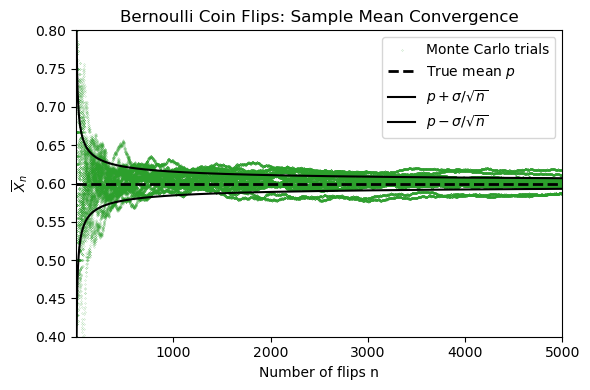

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))

# Thirty sample-mean trajectories from repeated experiments
for k in range(20):
    ax.scatter(n_vals, running_mean[k], 0.05,marker='.', color="tab:green")
ax.scatter(n_vals, running_mean[k], 0.05,marker='.', color="tab:green", label="Monte Carlo trials")

# Theoretical mean and LLN spread
ax.axhline(p_true, color="black", ls="--", lw=2, label="True mean $p$")
ax.plot(n_vals, upper_band, color="black", lw=1.5, label=r"$p + \sigma/\sqrt{n}$")
ax.plot(n_vals, lower_band, color="black", lw=1.5, label=r"$p - \sigma/\sqrt{n}$")

ax.set_title("Bernoulli Coin Flips: Sample Mean Convergence")
ax.set_xlabel("Number of flips n")
ax.set_ylabel(r"$\overline{X}_n$")
ax.set_xlim(1, N_max)
ax.set_ylim(0.4, 0.8)
ax.legend()
fig.tight_layout()
plt.show()

This $1/\sqrt{n}$ convergence rate is predicted by the Law of Large Numbers (LLN).

## Limit Theorems
### Law of Large Numbers (LLN)

#### Statement (informal)
Let $X_1, X_2, \dots$ be independent and identically distributed (i.i.d.) random variables with 
$$\mathbb{E}[X_i] = \mu, \qquad \mathrm{Var}(X_i)=\sigma^2<\infty. $$
Define the sample average  
```math
\overline{X}_n = \frac{1}{n}\sum_{i=1}^n X_i.
```

<!-- ```{admonition} Statement (informal) -->
As $n\to\infty$,
$$\overline{X}_n \to \mu \quad \text{with high probability}.$$
and
```math
\mathrm{Var}(\overline{X}_N)
= \mathrm{Var}\!\left(\frac{1}{N}\sum_{i=1}^N X_i\right)
= \frac{1}{N^2}\sum_{i=1}^N \mathrm{Var}(X_i)
= \frac{\sigma^2}{N}.
```
<!-- ``` -->

#### Intuition
- When averaging many independent measurements, random fluctuations “cancel out.”
- The average stabilizes around the true mean.
- The distance from the true mean (the standard deviation) scales as $1/\sqrt{N}$.
- In geophysics: stacking traces reduces noise because signal adds coherently, noise adds incoherently.

 
### Central Limit Theorem (CLT)
The Law of Large Numbers tells us that $\overline{X}_n$ gets close to $p$. The Central Limit Theorem goes further: it tells us the shape of the fluctuations around $p$.

#### Statement (informal)
Let $X_1,\dots,X_n$ be i.i.d. with mean $\mu$ and variance $\sigma^2$.

The normalized sum  
```math
Z_n=
\frac{\sum_{i=1}^n X_i - n\mu}{\sigma\sqrt{n}}
```
approaches a standard normal distribution as $n\to\infty$:
```math
Z_n \Rightarrow \mathcal{N}(0,1).
```

#### Intuition
- Many small independent effects aggregate to produce a Gaussian shape.
- Even if the underlying distribution is not Gaussian, the sum behaves Gaussian.
- Explains why normal noise models are widely applicable.

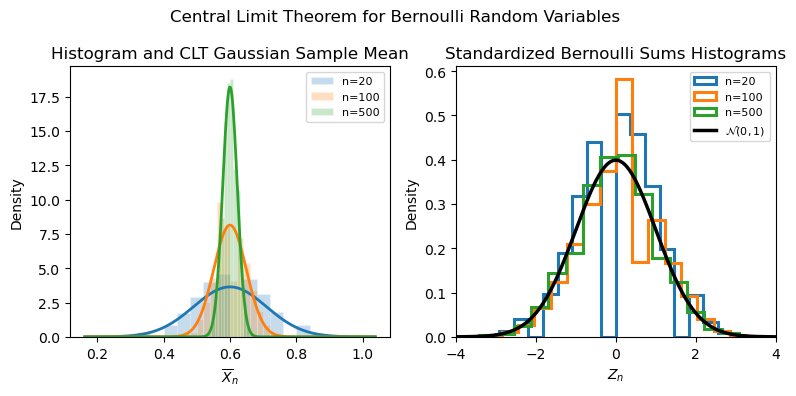

In [3]:
# CLT experiment: distribution of Bernoulli sample means and standardized sums

n_trials = 50000
n_values_clt = [20, 100, 500]
bins_n = 20

x_grid = np.linspace(-4, 4, 400)
normal_pdf = np.exp(-0.5 * x_grid**2) / np.sqrt(2 * np.pi)

# Simulate once per n, then reuse the same draws for both panels
sample_mean_by_n = {}
z_by_n = {}
for n in n_values_clt:
    samples = rng.binomial(1, p_true, size=(n_trials, n))
    sample_mean_by_n[n] = samples.mean(axis=1)
    z_by_n[n] = (samples.sum(axis=1) - n * p_true) / (sigma * np.sqrt(n))

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(8, 4))
colors = {20: "tab:blue", 100: "tab:orange", 500: "tab:green"}

# Left panel: distribution of sample mean for increasing n
mean_grid = np.linspace(
    p_true - 4 * sigma / np.sqrt(min(n_values_clt)),
    p_true + 4 * sigma / np.sqrt(min(n_values_clt)),
    400,
 )

for n in n_values_clt:
    sample_means = sample_mean_by_n[n]
    approx_sd = sigma / np.sqrt(n)
    normal_mean_pdf = np.exp(-0.5 * ((mean_grid - p_true) / approx_sd) ** 2) / (approx_sd * np.sqrt(2 * np.pi))

    ax_left.hist(
        sample_means,
        bins=bins_n,
        density=True,
        alpha=0.25,
        color=colors[n],
        edgecolor="white",
        linewidth=0.5,
        label=fr"n={n}",
    )
    ax_left.plot(
        mean_grid,
        normal_mean_pdf,
        color=colors[n],
        lw=2,
    )

ax_left.set_title("Histogram and CLT Gaussian Sample Mean")
ax_left.set_xlabel(r"$\overline{X}_n$")
ax_left.set_ylabel("Density")
# ax_left.set_xlim(0.2, 1)
# ax_left.set_ylim(0, 30)
ax_left.legend(fontsize=8)

# Right panel: standardized sample mean approaches N(0,1)
for n in n_values_clt:
    ax_right.hist(
        z_by_n[n],
        bins=bins_n,
        density=True,
        histtype="step",
        color=colors[n],
        lw=2.2,
        label=fr"n={n}",
    )

ax_right.plot(x_grid, normal_pdf, color="black", lw=2.5, label=r"$\mathcal{N}(0,1)$")
ax_right.set_title("Standardized Bernoulli Sums Histograms")
ax_right.set_xlabel(r"$Z_n$")
ax_right.set_ylabel("Density")
ax_right.set_xlim(-4, 4)
ax_right.legend(fontsize=8)

fig.suptitle("Central Limit Theorem for Bernoulli Random Variables", fontsize=12)
fig.tight_layout()
plt.show()

## Estimating Variance

Let $X_1, \dots, X_n$ be i.i.d. samples from a distribution with mean $\mu$ and variance $\sigma^2$.

We have the sample mean

$$
\bar{X} = \frac{1}{n}\sum_{i=1}^n X_i
$$

### The naive variance estimator
The naive estimator divides by $n$:
$$
s_n^2 = \frac{1}{n}\sum_{i=1}^n (X_i - \bar{X})^2
$$
This estimator is **biased**, meaning

$$
\mathbb{E}[s_n^2] = \frac{n-1}{n}\sigma^2
$$

It systematically underestimates the true variance.

### Unbiased Variance Estimator (Bessel's Correction)

To remove the bias, divide by $n - 1$:
$$
s^2 = \frac{1}{n-1}\sum_{i=1}^n (X_i - \bar{X})^2
$$
Then
$$
\mathbb{E}[s^2] = \sigma^2
$$

so this estimator is **unbiased**.

Intuition: Estimating the mean $\bar{X}$ from the same data uses up one degree of freedom.
Thus, dividing by $n-1$ compensates for the fact that the residuals $(X_i - \bar{X})$ are constrained to sum to zero.

### Remarks
The Bessel's correction has a smaller effects for larger $n$. Therefore, for large amount of data, either formula can be used. 

Note, the numpy `numpy.var` function defaults to the bias estimator. You can read about it [here](https://numpy.org/doc/stable/reference/generated/numpy.var.html).

## Confidence Intervals

### Definition

Let $\theta$ be an unknown population parameter and $\hat{\theta}$ an estimator based on a sample of size $n$.
A $(1-\alpha)\times 100\%$ **confidence interval** is a random interval $[L,\, U]$ — computed from the data — that satisfies

$$
\mathbb{P}(L \le \theta \le U) = 1 - \alpha
$$

For a 95% CI, $\alpha = 0.05$.

The interval is random because $L$ and $U$ depend on the sample. The correct interpretation is: if we repeated the experiment many times, $(1-\alpha)$ of those intervals would contain the true $\theta$. **A single realized interval either covers $\theta$ or it does not.**

### General CLT-based interval

Whenever the CLT applies, we have an approximate $(1-\alpha)$ confidence interval for $\mu$:

$$
\bar{X}_n \pm z_{\alpha/2} \, \frac{\hat{\sigma}}{\sqrt{n}}
$$

where $z_{\alpha/2}$ is the upper $\alpha/2$ quantile of the standard normal (e.g. $z_{0.025} = 1.96$ for 95% CI) and $\hat{\sigma}$ is an estimate of the population standard deviation.

The width of the interval shrinks like $1/\sqrt{n}$, consistent with the LLN rate we saw earlier.

### Illustration: Bernoulli coin-flip experiment

In the coin-flip example, we observe $n$ flips of a coin with unknown bias $p$ and estimate it with
$$
\hat{p} = \frac{1}{n}\sum_{i=1}^n X_i
$$
Since $\mathrm{Var}(X_i) = p(1-p)$, the CLT-based standard error is
$$
\mathrm{SE}(\hat{p}) = \sqrt{\frac{p(1-p)}{n}} \approx \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$
and the 95% confidence interval is
$$
\hat{p} \pm 1.96 \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$
This is consistent with the $1/\sqrt{n}$ band we plotted in the LLN figure: the confidence interval is essentially one snapshot of that shrinking uncertainty band, evaluated at your observed $\hat{p}$.

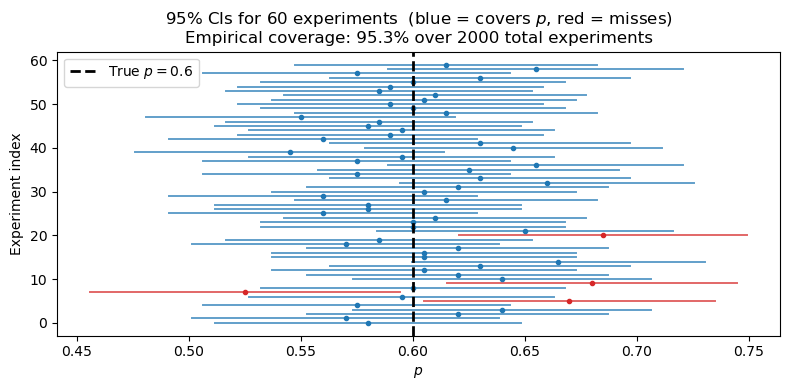

In [6]:
# Empirically test the 95% CLT confidence interval for a Bernoulli parameter

n_flips = 200          # sample size per experiment
n_experiments = 2000  # number of repeated experiments
z_95 = 1.96           # z-score for 95% CI

# Simulate many independent experiments, each with n_flips coin flips
all_flips = rng.binomial(1, p_true, size=(n_experiments, n_flips))

# Estimate p and the 95% CI for each experiment
p_hat = all_flips.mean(axis=1)
se = np.sqrt(p_hat * (1 - p_hat) / n_flips)
ci_lower = p_hat - z_95 * se
ci_upper = p_hat + z_95 * se

# Check which intervals actually contain the true p
contains = (ci_lower <= p_true) & (p_true <= ci_upper)
coverage = contains.mean()

# Plot the first 60 intervals, highlighting misses
n_show = 60
fig, ax = plt.subplots(figsize=(8, 4))

for i in range(n_show):
    color = "tab:blue" if contains[i] else "tab:red"
    ax.plot([ci_lower[i], ci_upper[i]], [i, i], color=color, lw=1.4, alpha=0.7)
    ax.plot(p_hat[i], i, "o", color=color, ms=3)

ax.axvline(p_true, color="black", lw=2, ls="--", label=f"True $p = {p_true}$")
ax.set_xlabel(r"$p$")
ax.set_ylabel("Experiment index")
ax.set_title(
    f"95% CIs for {n_show} experiments  "
    f"(blue = covers $p$, red = misses)\n"
    f"Empirical coverage: {coverage*100:.1f}% over {n_experiments} total experiments"
)
ax.legend()
fig.tight_layout()
plt.show()

## Null Hypothesis and Statistical Testing

So far, we have focused on estimation: using data to estimate an unknown parameter such as $p$ or $\mu$. Often, however, the goal is to evaluate a specific claim about that parameter.

### Null and alternative hypotheses

A **null hypothesis** $H_0$ is a baseline claim about the parameter. It usually represents a default position, such as “no effect,” “no difference,” or a specific reference value.

An **alternative hypothesis** $H_A$ is the competing claim we would support if the data look inconsistent with $H_0$.

For the Bernoulli coin example, we might test whether the coin is fair:

$$
H_0: p = 0.5
\qquad \text{versus} \qquad
H_A: p \ne 0.5
$$

Here, $H_0$ says the probability of heads is exactly $0.5$, while $H_A$ says it is different from $0.5$.

### General idea of a statistical test

A **statistical test** asks: if the null hypothesis were true, would the statistic we observed be unusually far from what $H_0$ predicts?

The usual ingredients are:

1. A null hypothesis $H_0$ and an alternative hypothesis $H_A$.
2. A test statistic computed from the sample.
3. A reference distribution for that statistic assuming $H_0$ is true.
4. A rule for deciding whether the observed result is surprising enough to reject $H_0$.

### Bernoulli example with the CLT

If $X_1, \dots, X_n \sim \mathrm{Bernoulli}(p)$, then the sample proportion is

$$
\hat{p} = \frac{1}{n}\sum_{i=1}^n X_i
$$

Under the null hypothesis $H_0: p = p_0$, the CLT tells us that for large $n$,

$$
\hat{p} \approx \mathcal{N}\!\left(p_0,\, \frac{p_0(1-p_0)}{n}\right)
$$

so the standardized test statistic is approximately

$$
Z = \frac{\hat{p} - p_0}{\sqrt{p_0(1-p_0)/n}} \approx \mathcal{N}(0,1)
$$

If $|Z|$ is large, then the observed $\hat{p}$ is far from what we would expect if $H_0$ were true, which is evidence against the null hypothesis.

### p-value and significance level

The **p-value** is the probability, assuming $H_0$ is true, of obtaining a result at least as extreme as the one observed.

A small p-value means the data would be unusual under the null model. A common threshold is $\alpha = 0.05$:

- If the p-value is less than $\alpha$, we **reject** $H_0$.
- If the p-value is greater than or equal to $\alpha$, we **fail to reject** $H_0$.

Failing to reject $H_0$ does **not** prove that $H_0$ is true. It only means the data do not provide strong enough evidence against it.

### Connection to confidence intervals

For a two-sided test, there is a direct link to the confidence intervals we already introduced: a level-$\alpha$ test rejects $H_0: \theta = \theta_0$ exactly when $\theta_0$ falls outside the $(1-\alpha)$ confidence interval for $\theta$.

So confidence intervals and hypothesis tests are two ways of expressing the same inferential uncertainty.

### Important interpretation

A hypothesis test is a decision rule with long-run error properties. It does not tell us the probability that the null hypothesis is true, and statistical significance does not automatically imply scientific or practical importance.

## Key Points
- Statistical inference uses observed data to learn about unknown features of a population or data-generating process.
- A parameter is an unknown quantity that describes a population, a sample is a finite set of observations, and a statistic is a quantity computed from that sample to estimate the parameter.
- The Law of Large Numbers says that the sample mean approaches the true mean as the sample size increases.
- The variability of the sample mean scales like $1/\sqrt{n}$, so larger samples produce more stable estimates.
- The Central Limit Theorem says that properly standardized sums or sample means become approximately Gaussian for large $n$, even when the original data are not Gaussian.
- The variance estimator that divides by $n$ is biased low; dividing by $n-1$ gives an unbiased estimator.
- A confidence interval is a procedure that captures the true parameter with a stated long-run frequency, not a probability statement about a single fixed parameter after the data are observed.
- A null hypothesis is a baseline claim about a parameter, and a statistical test checks whether the observed data would be unusually inconsistent with that claim.
- A p-value measures how surprising the observed result would be if the null hypothesis were true.
- Confidence intervals and two-sided hypothesis tests are closely connected: a null value is rejected at level $\alpha$ when it lies outside the corresponding $(1-\alpha)$ confidence interval.
- Confidence interval width shrinks as sample size increases.